# Interpolación series de tiempo de casos de influenza

In [1]:
# Importamos librerias
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d, PchipInterpolator, make_interp_spline
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
influenza_seasons = pd.read_csv("influenza_seasons_clean.csv")
influenza_seasons .head()

,TEMPORADA,FECHA_SINTOMAS,YEAR_EPI,SEMANA_EPI,CONFIRMADO_FLU,SECTOR,SEMANA_CALENDARIO,SEMANA_RELATIVA,GRUPO_EDAD,ENTIDAD_RES,CVE_ENTIDAD
0,2024-2025,2024-09-01,2024,36,SI,SSA,2024-SE36,1,0-4 años,YUCATÁN,31
1,2024-2025,2024-09-01,2024,36,SI,IMSS Bienestar OPD,2024-SE36,1,5-19 años,QUINTANA ROO,23
2,2024-2025,2024-09-01,2024,36,SI,SSA,2024-SE36,1,20-64 años,YUCATÁN,31
3,2024-2025,2024-09-01,2024,36,SI,ISSSTE,2024-SE36,1,5-19 años,GUERRERO,12
4,2024-2025,2024-09-01,2024,36,SI,SSA,2024-SE36,1,20-64 años,YUCATÁN,31


Contamos el número de casos por semana

In [3]:
# Agrupamos por Temporada y Semana Relativa
weekly_counts = (
    influenza_seasons
    .groupby(['TEMPORADA', 'SEMANA_RELATIVA'])
    .size()
    .reset_index(name='CASOS')
)
weekly_counts

,TEMPORADA,SEMANA_RELATIVA,CASOS
0,2024-2025,1,134
1,2024-2025,2,145
2,2024-2025,3,162
3,2024-2025,4,125
4,2024-2025,5,102
...,...,...,...
76,2025-2026,29,224
77,2025-2026,30,187
78,2025-2026,31,106
79,2025-2026,32,39


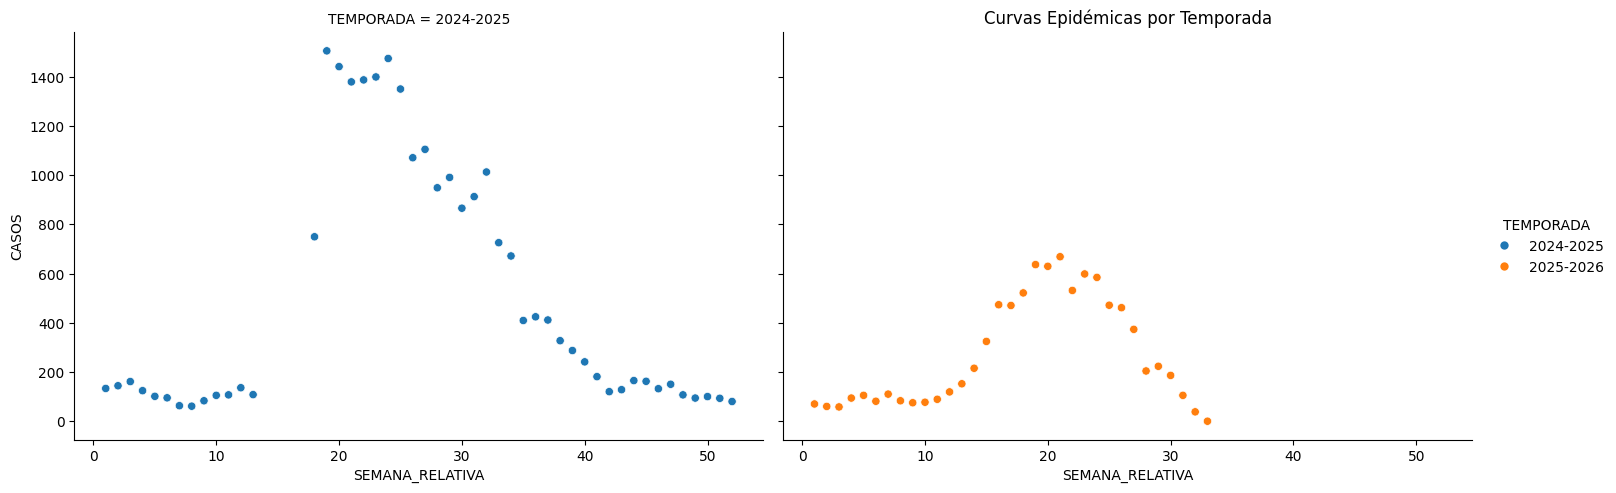

In [11]:
# Esto creará una línea por cada temporada sobre el mismo eje X (semanas)
sns.relplot(
    data=weekly_counts, 
    x='SEMANA_RELATIVA', 
    y='CASOS', 
    hue='TEMPORADA', 
    kind='scatter', 
    col='TEMPORADA',
    height=5, 
    aspect=1.5
)
plt.title('Curvas Epidémicas por Temporada')
plt.show()

In [5]:
weekly_countsT1 = weekly_counts[weekly_counts['TEMPORADA']=='2024-2025']
weekly_countsT1.head()

,TEMPORADA,SEMANA_RELATIVA,CASOS
0,2024-2025,1,134
1,2024-2025,2,145
2,2024-2025,3,162
3,2024-2025,4,125
4,2024-2025,5,102


In [6]:
L = len(weekly_countsT1)
SemanasReporte = np.array([weekly_countsT1['SEMANA_RELATIVA'][i] for i in range(L)])
Infecciones = np.array([weekly_countsT1['CASOS'][i] for i in range(L)])

SemanasNoReporte = [i for i in range(1,53) if i not in SemanasReporte]

In [7]:
pchip = PchipInterpolator(SemanasReporte, Infecciones)
X = np.linspace(1, 52, 3*104)
Y = pchip(X)

InfeccionPrediccion = pchip(SemanasNoReporte)

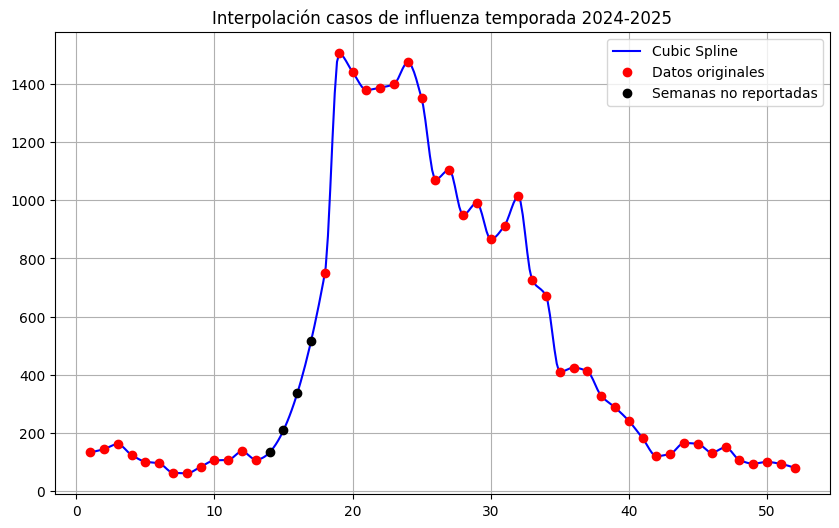

In [8]:
plt.figure(figsize=(10,6))
plt.plot(X, Y, label='Cubic Spline', color='blue')
plt.plot(SemanasReporte, Infecciones, 'ro', label='Datos originales')
plt.plot(SemanasNoReporte, InfeccionPrediccion, 'ko', label='Semanas no reportadas')
plt.title("Interpolación casos de influenza temporada 2024-2025")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:


interpoladores = dict(funciones, nombres_interpoladores)

TypeError: dict expected at most 1 argument, got 2

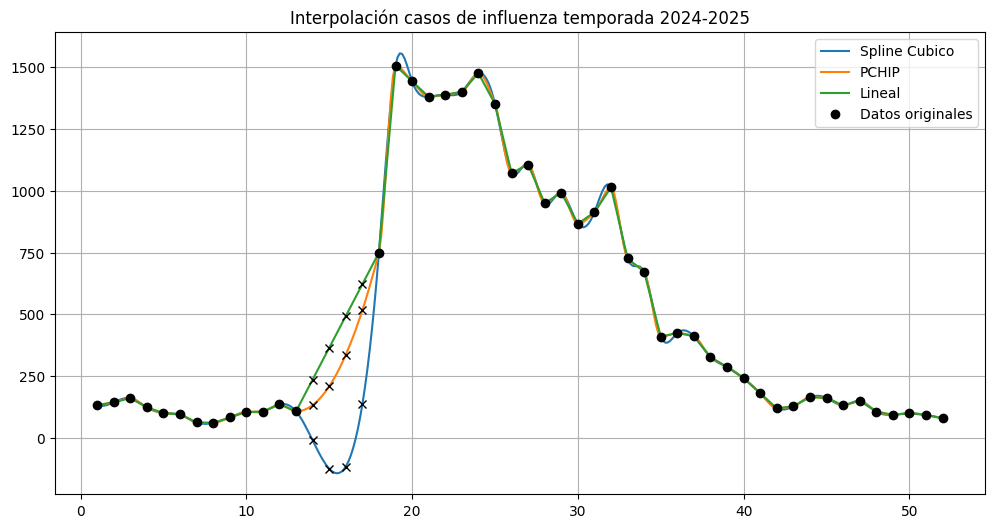

In [50]:
interpolador = [CubicSpline, PchipInterpolator, interp1d]
nombre= ["Spline Cubico", "PCHIP", "Lineal" ]

plt.figure(figsize=(12,6))
X = np.linspace(1, 52, 7*52)

for i in range(3):
    p = interpolador[i](SemanasReporte, Infecciones)
    Y = p(X)
    InfeccionPrediccion = p(SemanasNoReporte)
    plt.plot(X, Y, label=nombre[i])
    plt.plot(SemanasNoReporte, InfeccionPrediccion, 'kx')


plt.plot(SemanasReporte, Infecciones, 'ko', label='Datos originales')
plt.title("Interpolación casos de influenza temporada 2024-2025")
plt.grid(True)
plt.legend()
plt.show()


# Modelos GLM

In [21]:
Influenza = np.array([[SemanasReporte[i], Infecciones[i]] for i in range(SemanasReporte.size)])
Xglm = Influenza[:, 0]
Xglm = sm.add_constant(Xglm)

yglm = Influenza[:, 1]

In [31]:
model = sm.GLM(yglm, Xglm, family=sm.families.Gaussian())
results=model.fit()
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   48
Model:                            GLM   Df Residuals:                       46
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      2.5127e+05
Method:                          IRLS   Log-Likelihood:                -365.51
Date:                Fri, 24 Apr 2026   Deviance:                   1.1559e+07
Time:                        15:10:18   Pearson chi2:                 1.16e+07
No. Iterations:                     3   Pseudo R-squ. (CS):           0.005036
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        559.1702    148.739      3.759      0.0

In [32]:
Imputaciones = []
for semana in SemanasNoReporte:
    test = np.array([1, semana])
    test = test.reshape(1,-1)
    Imputaciones.append(results.predict(test)[0])

In [33]:
XGLM = np.linspace(1, 52, 7*52)
YGLM = []
for x in XGLM:
    test = np.array([1, x])
    test = test.reshape(1,-1)
    YGLM.append(results.predict(test)[0])


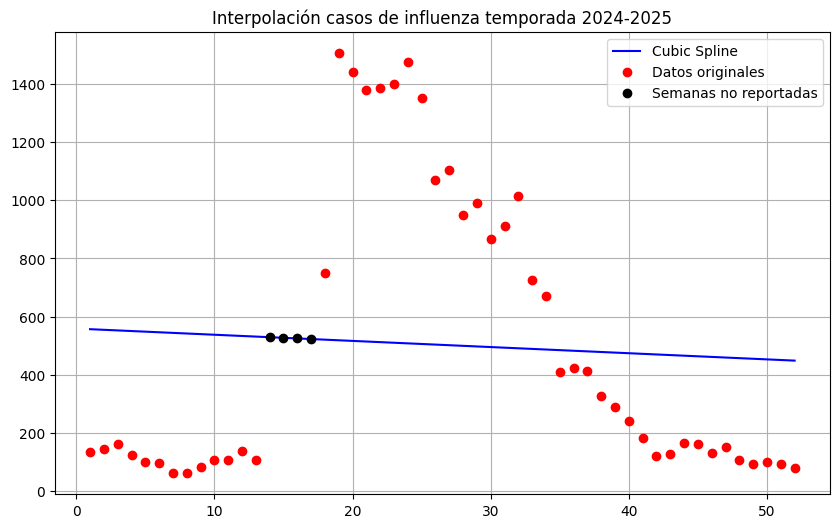

In [34]:
plt.figure(figsize=(10,6))
plt.plot(XGLM, YGLM, label='Cubic Spline', color='blue')
plt.plot(SemanasReporte, Infecciones, 'ro', label='Datos originales')
plt.plot(SemanasNoReporte, Imputaciones, 'ko', label='Semanas no reportadas')
plt.title("Interpolación casos de influenza temporada 2024-2025")
plt.grid(True)
plt.legend()
plt.show()